In [4]:
import pandas as pd

X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

print(f"✅ Data loaded!")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   Fraud in train : {y_train.sum()}")
print(f"   Fraud in test  : {y_test.sum()}")

✅ Data loaded!
   X_train : (454902, 30)
   X_test  : (56962, 30)
   Fraud in train : 227451
   Fraud in test  : 98


In [5]:
from sklearn.tree import DecisionTreeClassifier

In [6]:
dt_model = DecisionTreeClassifier(
    criterion='gini',   # or 'entropy'
    max_depth=10,       # prevents overfitting
    random_state=42
)

In [7]:
dt_model.fit(X_train, y_train)

print("Decision Tree training completed!")

Decision Tree training completed!


In [8]:
y_pred = dt_model.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9835504371335276

Confusion Matrix:
[[55946   918]
 [   19    79]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.08      0.81      0.14        98

    accuracy                           0.98     56962
   macro avg       0.54      0.89      0.57     56962
weighted avg       1.00      0.98      0.99     56962



In [10]:
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

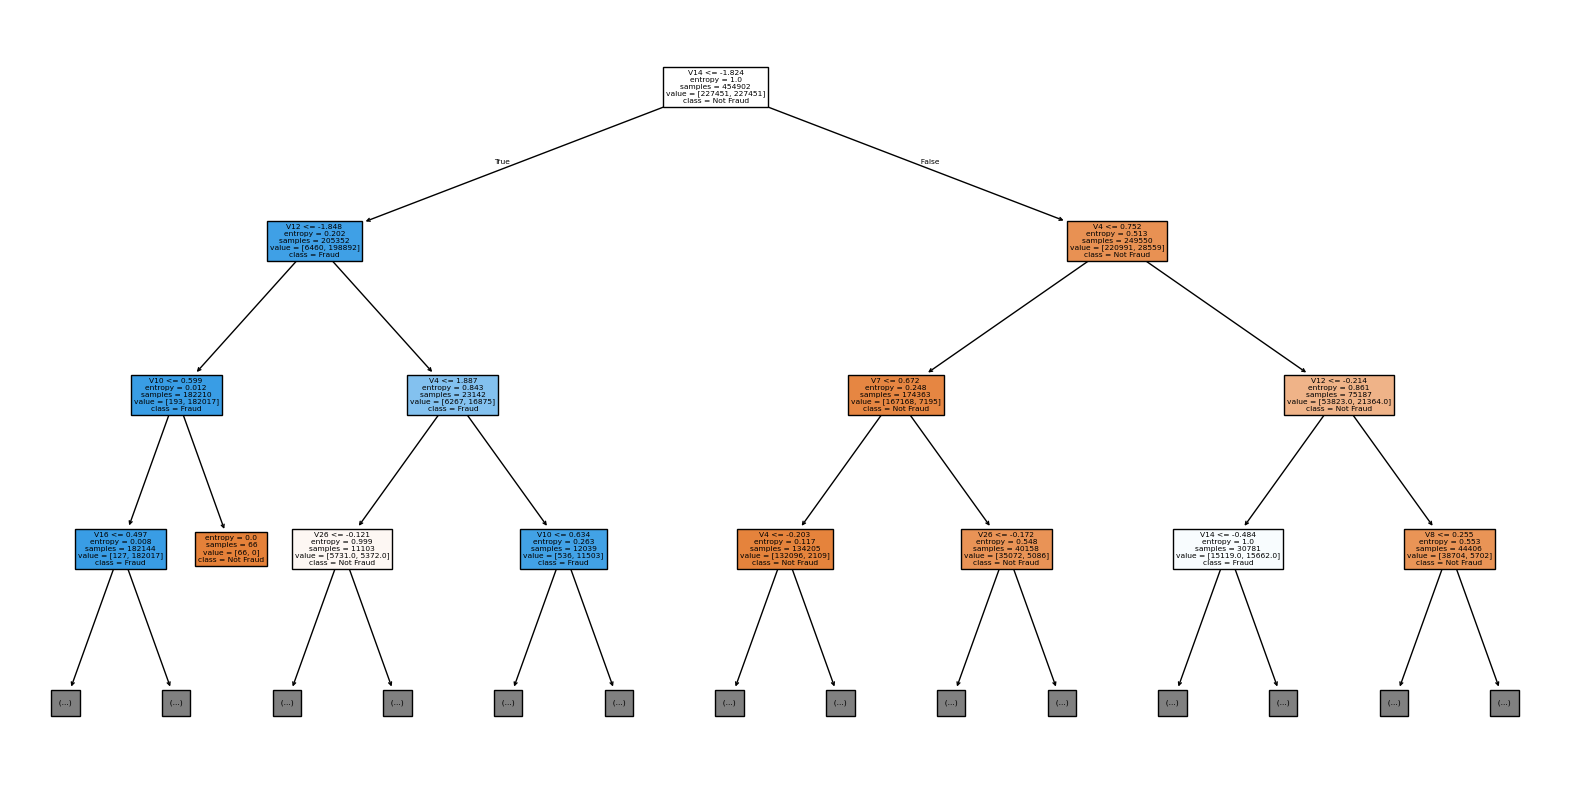

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    max_depth=3,
    filled=True,
    feature_names=X_train.columns,
    class_names=['Not Fraud','Fraud']
)

plt.show()

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 15],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 15}
